In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# セグメント解析: 基本パイプライン

**目的**: `SegmentTable` を使用して時刻キー付きデータ解析を管理する方法を学びます。

`SegmentTable` は、特定の時間セグメントに関連付けられたメタデータとペイロードデータ（TimeSeries や PSD など）のコンテナです。大規模なデータセットを効率的に扱うため、遅延読み込みをサポートしています。

## 1. SegmentTable の作成

GPS 開始・終了時刻を持つセグメントを定義した CSV ファイルからサンプルデータを読み込みます。

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from pathlib import Path

from gwexpy.table import SegmentTable

# Resolve the sample path robustly for both repo-root and notebook-dir execution.
csv_candidates = []
for root in [Path.cwd(), *Path.cwd().parents]:
    csv_candidates.extend([
        root / "docs" / "_static" / "samples" / "sample_segment_data.csv",
        root / "_static" / "samples" / "sample_segment_data.csv",
    ])

sample_csv = next((path for path in csv_candidates if path.exists()), None)
if sample_csv is None:
    tried = [str(path) for path in csv_candidates]
    raise FileNotFoundError(f"Could not find sample_segment_data.csv. Tried: {tried}")

st = SegmentTable.read(str(sample_csv))

print(st)
st.display().head()

   start  end label          span
0      0    4     A    (0.0, 4.0)
1      4    8     B    (4.0, 8.0)
2     10   13     C  (10.0, 13.0)
3     15   20     D  (15.0, 20.0)
4     22   25     E  (22.0, 25.0)


,start,end,label,span
0,0,4,A,"(0.0, 4.0)"
1,4,8,B,"(4.0, 8.0)"
2,10,13,C,"(10.0, 13.0)"
3,15,20,D,"(15.0, 20.0)"
4,22,25,E,"(22.0, 25.0)"


## 2. セグメントの可視化

セグメントのタイムラインを素早く可視化できます。

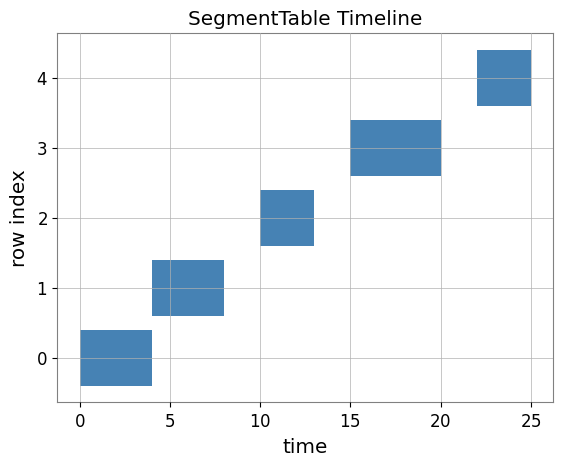

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
st.segments(ax=ax, label="Tutorial Segments")
plt.title("SegmentTable Timeline")
plt.show()

## 3. ペイロードの遅延読み込み

`SegmentTable` ではカラムに「ローダー」を紐付けることができます。データは実際にアクセスされたときのみ読み込まれます。

In [4]:
from gwexpy.noise.wave import gaussian


def noise_loader(segment):
    # Generate synthetic noise for the segment
    duration = float(segment[1] - segment[0])
    return gaussian(duration=duration, sample_rate=1024, t0=float(segment[0]))

# Note: Use add_series_column for lazy-loadable payload data (kind='timeseries', etc.)
st.add_series_column("noise", loader=noise_loader, kind="timeseries")

# Accessing the first row's noise (triggers loading)
data_0 = st.row(0)["noise"]
print(f"Loaded {len(data_0)} samples starting at GPS {data_0.t0.value}")

Loaded 4096 samples starting at GPS 0.0


## 4. 行ごとの処理

行をイテレートしたり、`apply` を使ってデータを処理したりできます。

In [5]:
# Calculate RMS for each noise segment
# Use add_column for lightweight metadata results
st.add_column("rms", data=[row["noise"].rms().value for row in st])
st.display()

,start,end,label,span,rms,noise
0,0,4,A,"(0.0, 4.0)",0.990834,<timeseries: 4096 samples>
1,4,8,B,"(4.0, 8.0)",0.999434,<timeseries: 4096 samples>
2,10,13,C,"(10.0, 13.0)",0.999872,<timeseries: 3072 samples>
3,15,20,D,"(15.0, 20.0)",0.998087,<timeseries: 5120 samples>
4,22,25,E,"(22.0, 25.0)",1.004844,<timeseries: 3072 samples>


## 5. 検証セル（NBMAKE）

In [6]:
assert "noise" in st.columns
assert len(st) > 0
print("Validation successful!")

Validation successful!
